In [28]:
import os


dataset_path = "/kaggle/input/datasets/radheshrestha/book-review-dataset/"

print(os.listdir(dataset_path))

['Book_review.csv']


In [29]:
import pandas as pd

In [30]:
df = pd.read_csv("/kaggle/input/datasets/radheshrestha/book-review-dataset/Book_review.csv")
print(df.head())
print(df.columns)

   Unnamed: 0  rating                                         reviewText  \
0           0       5  This book was the very first bookmobile book I...   
1           1       1  When I read the description for this book, I c...   
2           2       5  I just had to edit this review. This book is a...   
3           3       5  I don't normally buy 'mystery' novels because ...   
4           4       5  This isn't the kind of book I normally read, a...   

                           summary  
0                50 + years ago...  
1          Boring! Boring! Boring!  
2  Wiggleliscious/new toy ready/!!  
3                  Very good read.  
4                     Great Story!  
Index(['Unnamed: 0', 'rating', 'reviewText', 'summary'], dtype='object')


In [31]:
# Basic Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import warnings

warnings.filterwarnings('ignore')

# NLP Libraries
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from collections import Counter

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    SimpleRNN,
    LSTM,
    Dense,
    Dropout,
    Bidirectional,
    SpatialDropout1D
)

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Visualization
from wordcloud import WordCloud

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [32]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [ ]:
# Load Dataset
dataset_path = "/kaggle/input/datasets/radheshrestha/book-review-dataset/Book_review.csv"

# Load dataset
df = pd.read_csv(dataset_path)

# Display shape
print("Dataset Shape:", df.shape)

# Preview dataset
df.head()

Dataset Shape: (12000, 4)


,Unnamed: 0,rating,reviewText,summary
0,0,5,This book was the very first bookmobile book I...,50 + years ago...
1,1,1,"When I read the description for this book, I c...",Boring! Boring! Boring!
2,2,5,I just had to edit this review. This book is a...,Wiggleliscious/new toy ready/!!
3,3,5,I don't normally buy 'mystery' novels because ...,Very good read.
4,4,5,"This isn't the kind of book I normally read, a...",Great Story!


In [ ]:
# Basic Dataset Analysis
# Dataset Information
print(df.info())

# Missing Values
print("\nMissing Values:\n")
print(df.isnull().sum())

# Duplicate Records
print("\nDuplicate Rows:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  12000 non-null  int64 
 1   rating      12000 non-null  int64 
 2   reviewText  12000 non-null  object
 3   summary     11998 non-null  object
dtypes: int64(2), object(2)
memory usage: 375.1+ KB
None

Missing Values:

Unnamed: 0    0
rating        0
reviewText    0
summary       2
dtype: int64

Duplicate Rows: 0


sentiment
positive    6000
negative    4000
neutral     2000
Name: count, dtype: int64


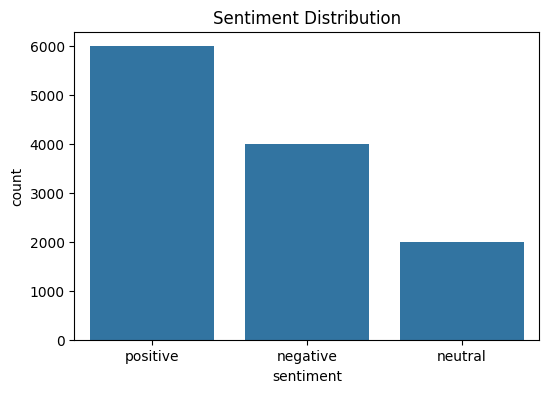

In [ ]:
# Create Sentiment Labels
def create_sentiment(rating):
    if rating <= 2:
        return "negative"
    elif rating == 3:
        return "neutral"
    else:
        return "positive"

df['sentiment'] = df['rating'].apply(create_sentiment)

# Check distribution
print(df['sentiment'].value_counts())

# Plot distribution
plt.figure(figsize=(6,4))
sns.countplot(x=df['sentiment'])
plt.title("Sentiment Distribution")
plt.show()

In [ ]:
# Combine Review + Summary
df['text'] = df['summary'].fillna('') + " " + df['reviewText'].fillna('')

df[['text', 'sentiment']].head()

,text,sentiment
0,50 + years ago... This book was the very first...,positive
1,Boring! Boring! Boring! When I read the descri...,negative
2,Wiggleliscious/new toy ready/!! I just had to ...,positive
3,Very good read. I don't normally buy 'mystery'...,positive
4,Great Story! This isn't the kind of book I nor...,positive


In [ ]:
# Advanced Text Cleaning
# Stopwords and Lemmatizer
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Contraction Dictionary
contractions = {
    "don't": "do not",
    "doesn't": "does not",
    "didn't": "did not",
    "can't": "cannot",
    "won't": "will not",
    "i'm": "i am",
    "it's": "it is",
    "you're": "you are",
    "they're": "they are",
    "that's": "that is",
    "wasn't": "was not",
    "weren't": "were not",
    "isn't": "is not",
    "aren't": "are not",
    "couldn't": "could not",
    "shouldn't": "should not",
    "wouldn't": "would not"
}

def clean_text(text):
    
    # Lowercase
    text = text.lower()
    
    # Expand contractions
    for word, expansion in contractions.items():
        text = text.replace(word, expansion)
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Tokenization
    tokens = word_tokenize(text)
    
    # Remove stopwords + lemmatization
    cleaned_tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words and len(word) > 2
    ]
    
    return " ".join(cleaned_tokens)

In [ ]:
# Apply Cleaning Function
# Apply preprocessing
df['clean_text'] = df['text'].apply(clean_text)

# Preview cleaned text
df[['text', 'clean_text']].head()

,text,clean_text
0,50 + years ago... This book was the very first...,year ago book first bookmobile book bought sch...
1,Boring! Boring! Boring! When I read the descri...,boring boring boring read description book cou...
2,Wiggleliscious/new toy ready/!! I just had to ...,wigglelisciousnew toy ready edit review book b...
3,Very good read. I don't normally buy 'mystery'...,good read normally buy mystery novel like howe...
4,Great Story! This isn't the kind of book I nor...,great story kind book normally read although t...


In [ ]:
# Check Sample Cleaned Reviews
for i in range(3):
    print(f"\nOriginal Review {i+1}:\n")
    print(df['text'][i])
    
    print(f"\nCleaned Review {i+1}:\n")
    print(df['clean_text'][i])
    
    print("="*100)


Original Review 1:

50 + years ago... This book was the very first bookmobile book I bought when I was in the school book club. I loved the story then and I bet a dollar to a donut I will love it again. If my memory serves, I bought this book in 5th grade. That would have been about 1961. I am looking forward to reliving the memories.

Cleaned Review 1:

year ago book first bookmobile book bought school book club loved story bet dollar donut love memory serf bought book grade would looking forward reliving memory

Original Review 2:

Boring! Boring! Boring! When I read the description for this book, I couldn't wait to read it. Once I downloaded it to my Kindle, I found it extremely hard to keep reading it.  To be honest, I stopped reading halfway through the book. It began slow and remained a slow, uninteresting read.  It lacked passion; not making love passion, but passion for life. Neither Jada or Aaron were interesting characters and the story was too, too `everything is perfect'. 

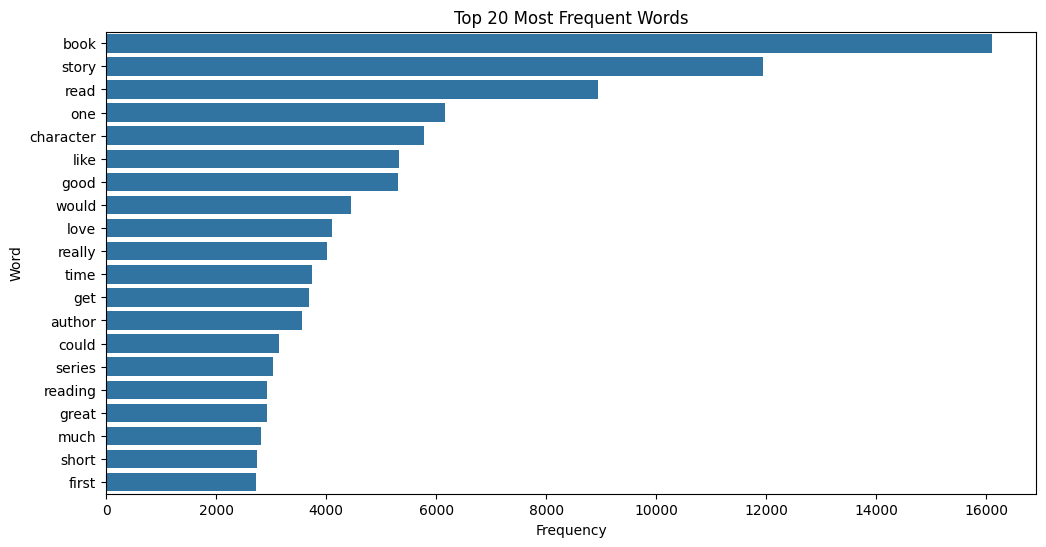

In [ ]:
# Most Frequent Words Visualization
# Combine all cleaned text
all_words = " ".join(df['clean_text'])

# Word frequency
word_freq = Counter(all_words.split())

# Top 20 words
common_words = word_freq.most_common(20)

# Convert to dataframe
freq_df = pd.DataFrame(common_words, columns=['Word', 'Frequency'])

# Plot
plt.figure(figsize=(12,6))
sns.barplot(data=freq_df, x='Frequency', y='Word')
plt.title("Top 20 Most Frequent Words")
plt.show()

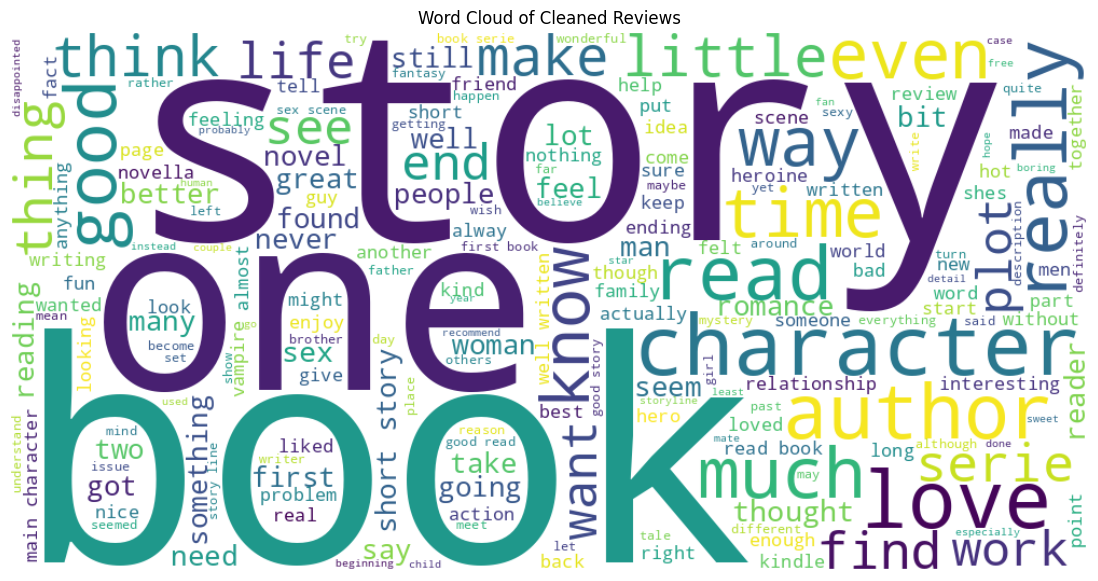

In [ ]:
# WordCloud Visualization
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(all_words)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Cleaned Reviews")
plt.show()

In [ ]:
# Encode Labels
# Label Encoding
encoder = LabelEncoder()

df['label'] = encoder.fit_transform(df['sentiment'])

# Label Mapping
label_mapping = dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))

print("Label Mapping:")
print(label_mapping)

Label Mapping:
{'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}


In [ ]:
# Train Test Split
# Features and Labels
X = df['clean_text']
y = df['label']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 9600
Testing Samples: 2400


In [ ]:
# Tokenization
# Vocabulary Size
vocab_size = 12000

# Tokenizer
tokenizer = Tokenizer(
    num_words=vocab_size,
    oov_token="<OOV>"
)

# Fit tokenizer
tokenizer.fit_on_texts(X_train)

# Convert text to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Word Index
word_index = tokenizer.word_index

print("Vocabulary Size:", len(word_index))

Vocabulary Size: 36481


Max Sequence Length: 182


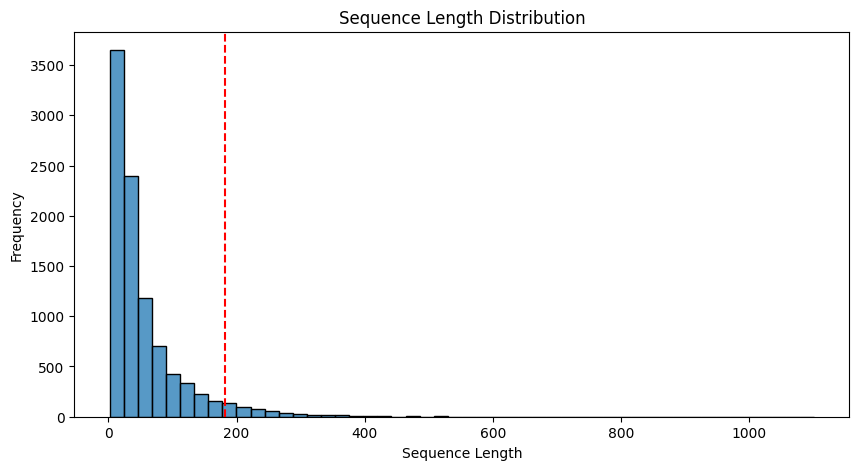

In [ ]:
# Percentile-Based Padding Length
# Calculate sequence lengths
sequence_lengths = [len(seq) for seq in X_train_seq]

# Use 95th percentile
max_length = int(np.percentile(sequence_lengths, 95))

print("Max Sequence Length:", max_length)

# Visualize distribution
plt.figure(figsize=(10,5))
sns.histplot(sequence_lengths, bins=50)
plt.axvline(max_length, color='red', linestyle='--')
plt.title("Sequence Length Distribution")
plt.xlabel("Sequence Length")
plt.ylabel("Frequency")
plt.show()

In [ ]:
# Padding Sequences
# Pad sequences
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

print("Training Shape:", X_train_pad.shape)
print("Testing Shape:", X_test_pad.shape)

Training Shape: (9600, 182)
Testing Shape: (2400, 182)


In [ ]:
# Early Stopping & Learning Rate Callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1
)

In [ ]:
# Build Model 1 (Simple RNN)
model_rnn = Sequential()

# Embedding Layer
model_rnn.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=128,
        input_length=max_length
    )
)

# Spatial Dropout
model_rnn.add(SpatialDropout1D(0.2))

# RNN Layer
model_rnn.add(
    SimpleRNN(
        128,
        return_sequences=False
    )
)

# Dense Layer
model_rnn.add(Dense(64, activation='relu'))

# Dropout
model_rnn.add(Dropout(0.5))

# Output Layer
model_rnn.add(Dense(3, activation='softmax'))

# Compile
model_rnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Summary
model_rnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train Model 1
history_rnn = model_rnn.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/15
240/240 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.4419 - loss: 1.0661 - val_accuracy: 0.5016 - val_loss: 1.0303 - learning_rate: 0.0010
Epoch 2/15
240/240 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.4751 - loss: 1.0429 - val_accuracy: 0.5016 - val_loss: 1.0096 - learning_rate: 0.0010
Epoch 3/15
240/240 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.4957 - loss: 1.0241 - val_accuracy: 0.5016 - val_loss: 1.0071 - learning_rate: 0.0010
Epoch 4/15
240/240 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.4927 - loss: 1.0194 - val_accuracy: 0.5016 - val_loss: 1.0077 - learning_rate: 0.0010
Epoch 5/15
237/240 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4987 - loss: 1.0214
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
240/240 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.4987 - loss: 1.0214 - val_accuracy: 0.5016 - val_loss: 1.0111 - learning_rate: 0.0010
Epoch 6/15
240/240 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.4966 - loss: 1.0

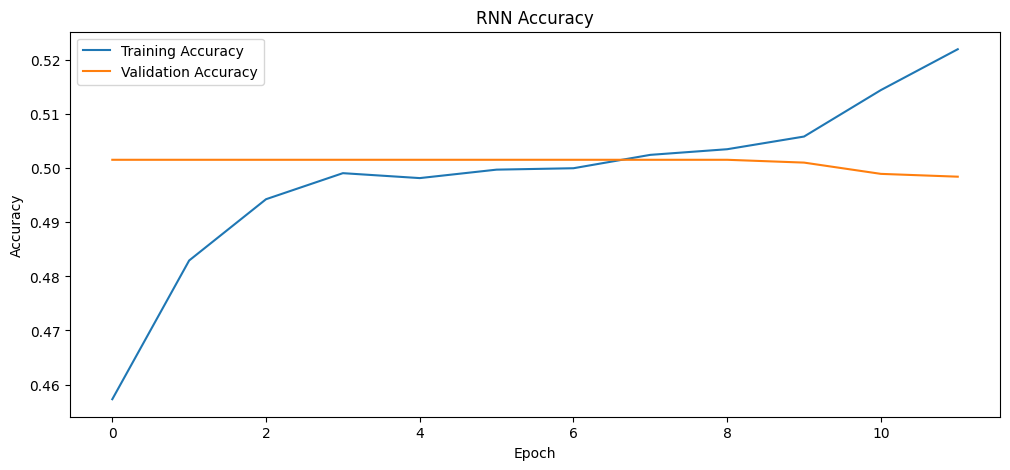

In [ ]:
# Plot Accuracy and Loss
# Accuracy Plot
plt.figure(figsize=(12,5))

plt.plot(history_rnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_rnn.history['val_accuracy'], label='Validation Accuracy')

plt.title("RNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

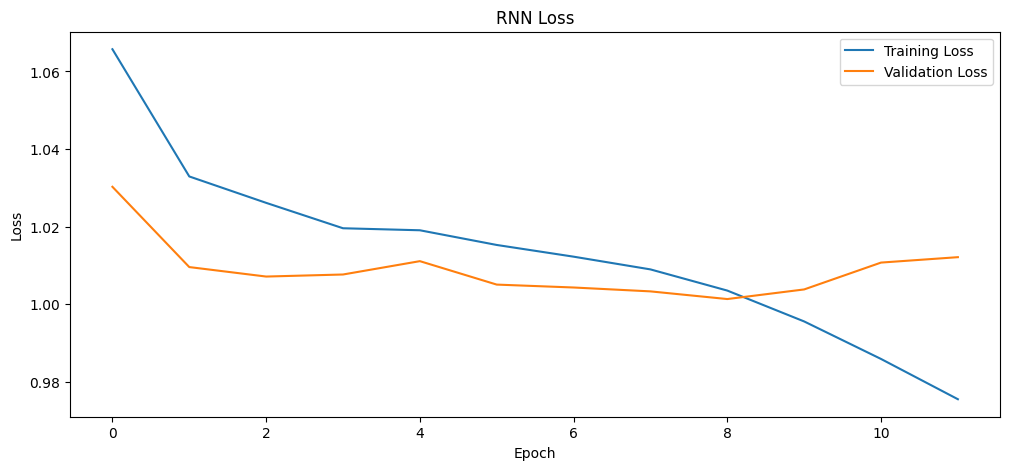

In [51]:
# Loss Plot
plt.figure(figsize=(12,5))

plt.plot(history_rnn.history['loss'], label='Training Loss')
plt.plot(history_rnn.history['val_loss'], label='Validation Loss')

plt.title("RNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [52]:
# Final Epoch Metrics

train_acc = history_rnn.history['accuracy'][-1]
val_acc = history_rnn.history['val_accuracy'][-1]

train_loss = history_rnn.history['loss'][-1]
val_loss = history_rnn.history['val_loss'][-1]

print(f"Final Training Accuracy: {train_acc:.4f}")
print(f"Final Validation Accuracy: {val_acc:.4f}")

print(f"Final Training Loss: {train_loss:.4f}")
print(f"Final Validation Loss: {val_loss:.4f}")

Final Training Accuracy: 0.5220
Final Validation Accuracy: 0.4984
Final Training Loss: 0.9755
Final Validation Loss: 1.0121


75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Test Accuracy: 0.49916666666666665

Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       800
           1       0.25      0.00      0.00       400
           2       0.50      1.00      0.67      1200

    accuracy                           0.50      2400
   macro avg       0.25      0.33      0.22      2400
weighted avg       0.29      0.50      0.33      2400



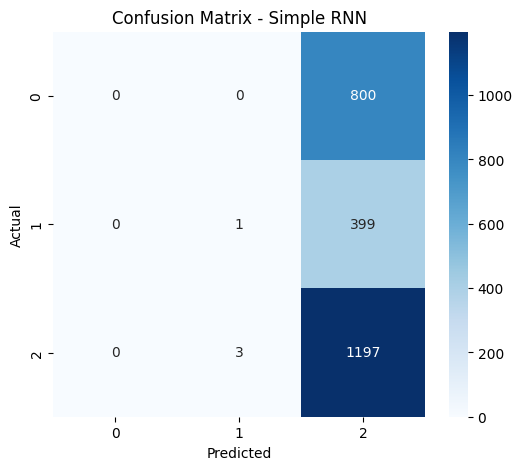

In [ ]:
# Evaluate RNN Predictions
# Predictions
y_pred_probs = model_rnn.predict(X_test_pad)

# Convert probabilities to class labels
y_pred = np.argmax(y_pred_probs, axis=1)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy:", accuracy)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - Simple RNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [54]:
# SAVE SIMPLE RNN MODEL
model_rnn.save("simple_rnn_model.keras")
print("Simple RNN Model Saved Successfully")

Simple RNN Model Saved Successfully


In [ ]:
# Build LSTM Model
model_lstm = Sequential()

# Embedding Layer
model_lstm.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=128,
        input_length=max_length
    )
)

# Spatial Dropout
model_lstm.add(SpatialDropout1D(0.3))

# Bidirectional LSTM
model_lstm.add(
    Bidirectional(
        LSTM(
            64,
            dropout=0.3,
            recurrent_dropout=0.3
        )
    )
)

# Dense Layer
model_lstm.add(Dense(64, activation='relu'))

# Dropout
model_lstm.add(Dropout(0.5))

# Output Layer
model_lstm.add(Dense(3, activation='softmax'))

# Compile
model_lstm.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Summary
model_lstm.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train LSTM
history_lstm = model_lstm.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 71s 521ms/step - accuracy: 0.5173 - loss: 0.9885 - val_accuracy: 0.7297 - val_loss: 0.6826 - learning_rate: 0.0010
Epoch 2/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 61s 512ms/step - accuracy: 0.7642 - loss: 0.6081 - val_accuracy: 0.7464 - val_loss: 0.6402 - learning_rate: 0.0010
Epoch 3/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 61s 511ms/step - accuracy: 0.8109 - loss: 0.4858 - val_accuracy: 0.7490 - val_loss: 0.6605 - learning_rate: 0.0010
Epoch 4/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 474ms/step - accuracy: 0.8563 - loss: 0.3810
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
120/120 ━━━━━━━━━━━━━━━━━━━━ 61s 512ms/step - accuracy: 0.8562 - loss: 0.3811 - val_accuracy: 0.7370 - val_loss: 0.7564 - learning_rate: 0.0010
Epoch 5/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 61s 509ms/step - accuracy: 0.8837 - loss: 0.3210 - val_accuracy: 0.7271 - val_loss: 0.7973 - learning_rate: 5.0000e-04


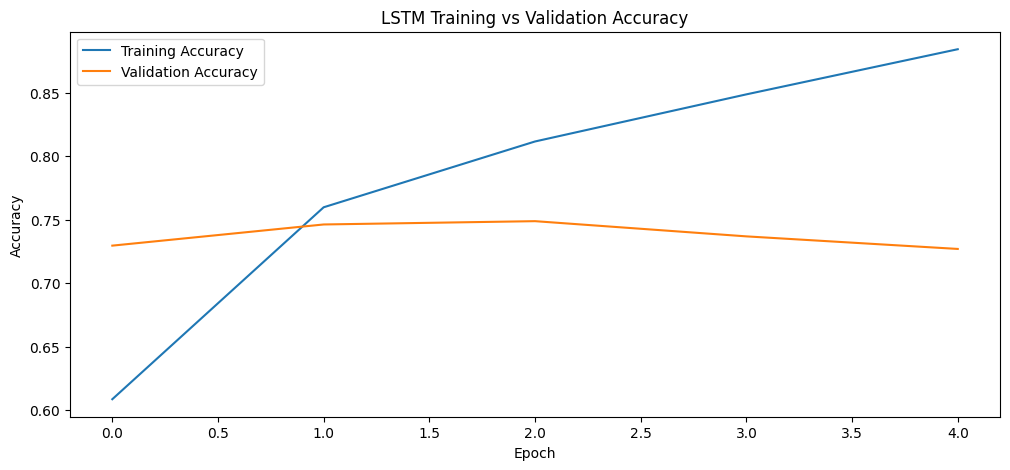

In [57]:
# LSTM Accuracy Graph
plt.figure(figsize=(12,5))

plt.plot(history_lstm.history['accuracy'], label='Training Accuracy')
plt.plot(history_lstm.history['val_accuracy'], label='Validation Accuracy')

plt.title("LSTM Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

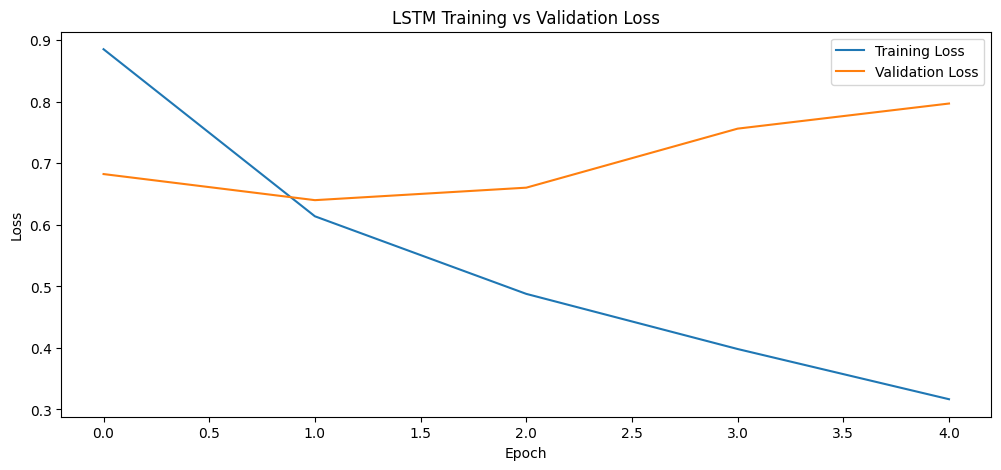

In [58]:
# LSTM Loss Graph
plt.figure(figsize=(12,5))

plt.plot(history_lstm.history['loss'], label='Training Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')

plt.title("LSTM Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

75/75 ━━━━━━━━━━━━━━━━━━━━ 11s 143ms/step
LSTM Test Accuracy: 0.74125

Classification Report:

              precision    recall  f1-score   support

           0       0.73      0.82      0.77       800
           1       0.57      0.06      0.10       400
           2       0.76      0.91      0.83      1200

    accuracy                           0.74      2400
   macro avg       0.69      0.60      0.57      2400
weighted avg       0.72      0.74      0.69      2400



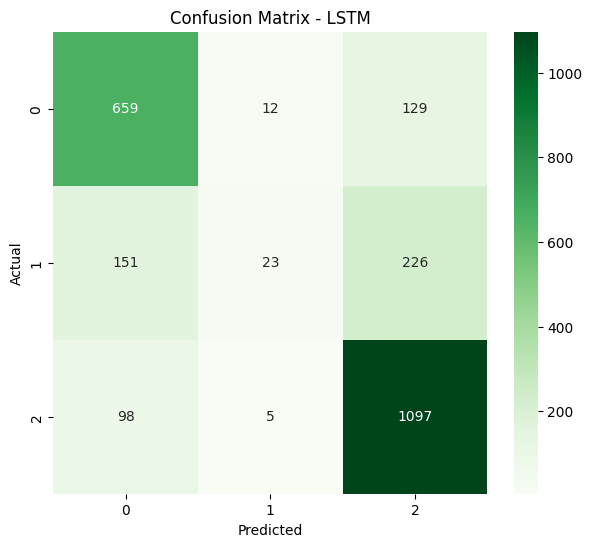

In [ ]:
# LSTM Evaluation
# Predict probabilities
y_pred_probs_lstm = model_lstm.predict(X_test_pad)

# Convert to class labels
y_pred_lstm = np.argmax(y_pred_probs_lstm, axis=1)

# Accuracy
lstm_accuracy = accuracy_score(y_test, y_pred_lstm)

print("LSTM Test Accuracy:", lstm_accuracy)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lstm))

# Confusion Matrix
cm_lstm = confusion_matrix(y_test, y_pred_lstm)

# Plot
plt.figure(figsize=(7,6))
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Greens')

plt.title("Confusion Matrix - LSTM")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [60]:
model_lstm.save("lstm_model.keras")
print("LSTM model saved successfully")

LSTM model saved successfully


In [61]:
import pickle

# Save tokenizer
with open("tokenizer.pkl", "wb") as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

print("Tokenizer Saved")

Tokenizer Saved


In [ ]:
# Install Compatible Versions
!pip install numpy==1.23.5
!pip install gensim
!pip install jax==0.4.13

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 94.5 MB/s eta 0:00:0000:010:01
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 18.3 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for jax: filename=jax-0.4.13-py3-none-any.whl size=1518818 sha256=0183eaae938692b91fe57f7295f3b5970b2f0f9dcd9d9

In [63]:
!pip uninstall -y smart_open
!pip install smart_open==6.4.0

Found existing installation: smart_open 7.5.1
Uninstalling smart_open-7.5.1:
  Successfully uninstalled smart_open-7.5.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.0/57.0 kB 2.5 MB/s eta 0:00:00


In [ ]:
# Import Gensim
import gensim.downloader as api

In [66]:
# STEP 27 — Load Pretrained Embeddings
embedding_model = api.load("glove-twitter-100")

print("Word2Vec Model Loaded")

Word2Vec Model Loaded


In [ ]:
# Create Embedding Matrix
embedding_dim = 100

embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, index in tokenizer.word_index.items():
    
    if index < vocab_size:
        
        try:
            embedding_vector = embedding_model[word]
            embedding_matrix[index] = embedding_vector
        
        except KeyError:
            continue

print("Embedding Matrix Shape:", embedding_matrix.shape)

Embedding Matrix Shape: (12000, 100)


In [ ]:
# Better EarlyStopping
early_stopping_w2v = EarlyStopping(
    monitor='val_loss',
    patience=2,
    verbose=1,
    restore_best_weights=True
)

In [ ]:
# Build Word2Vec LSTM Model
model_w2v = Sequential()

# Pretrained Embedding Layer
model_w2v.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        input_length=max_length,
        trainable=False
    )
)

# Spatial Dropout
model_w2v.add(SpatialDropout1D(0.2))

# Bidirectional LSTM
model_w2v.add(
    Bidirectional(
        LSTM(
            128,
            dropout=0.3,
            recurrent_dropout=0.3
        )
    )
)

# Dense Layer
model_w2v.add(Dense(64, activation='relu'))

# Dropout
model_w2v.add(Dropout(0.5))

# Output Layer
model_w2v.add(Dense(3, activation='softmax'))

# Compile
model_w2v.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Summary
model_w2v.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │     1,200,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_3             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,200,000 (4.58 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,200,000 (4.58 MB)

In [ ]:
# Train Word2Vec Model
history_w2v = model_w2v.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    callbacks=[early_stopping_w2v, reduce_lr],
    verbose=1
)

Epoch 1/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 56s 432ms/step - accuracy: 0.5387 - loss: 0.9718 - val_accuracy: 0.6755 - val_loss: 0.7742 - learning_rate: 0.0010
Epoch 2/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 51s 429ms/step - accuracy: 0.6608 - loss: 0.8153 - val_accuracy: 0.6958 - val_loss: 0.7367 - learning_rate: 0.0010
Epoch 3/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 51s 425ms/step - accuracy: 0.6864 - loss: 0.7698 - val_accuracy: 0.6943 - val_loss: 0.7307 - learning_rate: 0.0010
Epoch 4/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 51s 428ms/step - accuracy: 0.6675 - loss: 0.7974 - val_accuracy: 0.6969 - val_loss: 0.7279 - learning_rate: 0.0010
Epoch 5/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 51s 426ms/step - accuracy: 0.6880 - loss: 0.7644 - val_accuracy: 0.7036 - val_loss: 0.7228 - learning_rate: 0.0010
Epoch 6/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 51s 425ms/step - accuracy: 0.7043 - loss: 0.7336 - val_accuracy: 0.7089 - val_loss: 0.6925 - learning_rate: 0.0010
Epoch 7/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 51s 426ms/step - accuracy: 0.7

In [75]:
# SAVE WORD2VEC MODEL
model_w2v.save("word2vec_lstm_model.keras")
print("word2vec_lstm_model saved")

word2vec_lstm_model saved


75/75 ━━━━━━━━━━━━━━━━━━━━ 12s 148ms/step
Word2Vec LSTM Accuracy: 0.725

Classification Report:

              precision    recall  f1-score   support

           0       0.66      0.85      0.75       800
           1       0.39      0.08      0.14       400
           2       0.80      0.85      0.82      1200

    accuracy                           0.72      2400
   macro avg       0.62      0.60      0.57      2400
weighted avg       0.68      0.72      0.68      2400



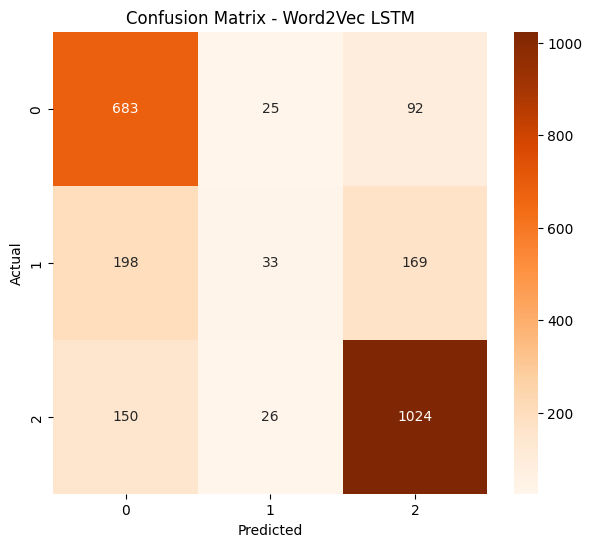

In [ ]:
# Evaluate Word2Vec Model
# Predictions
y_pred_probs_w2v = model_w2v.predict(X_test_pad)

# Convert probabilities
y_pred_w2v = np.argmax(y_pred_probs_w2v, axis=1)

# Accuracy
w2v_accuracy = accuracy_score(y_test, y_pred_w2v)

print("Word2Vec LSTM Accuracy:", w2v_accuracy)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_w2v))

# Confusion Matrix
cm_w2v = confusion_matrix(y_test, y_pred_w2v)

plt.figure(figsize=(7,6))
sns.heatmap(cm_w2v, annot=True, fmt='d', cmap='Oranges')

plt.title("Confusion Matrix - Word2Vec LSTM")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

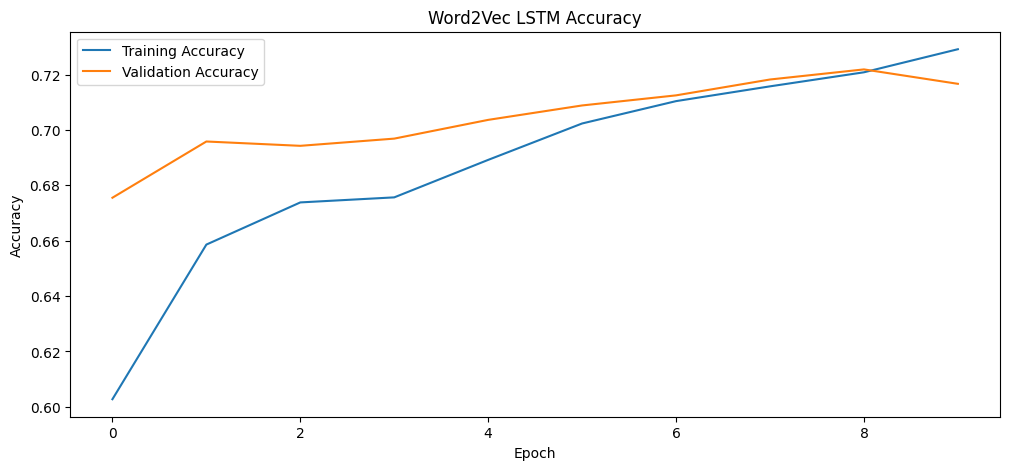

In [ ]:
# Accuracy Graph for Word2Vec
plt.figure(figsize=(12,5))

plt.plot(history_w2v.history['accuracy'], label='Training Accuracy')
plt.plot(history_w2v.history['val_accuracy'], label='Validation Accuracy')

plt.title("Word2Vec LSTM Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

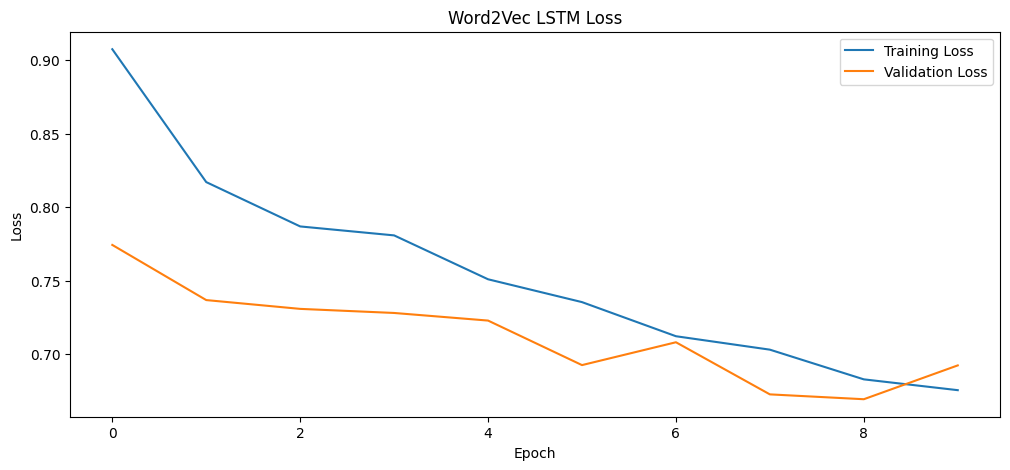

In [ ]:
# Loss Graph for Word2Vec
plt.figure(figsize=(12,5))

plt.plot(history_w2v.history['loss'], label='Training Loss')
plt.plot(history_w2v.history['val_loss'], label='Validation Loss')

plt.title("Word2Vec LSTM Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [79]:
# Overfitting Analysis

train_acc_w2v = history_w2v.history['accuracy'][-1]
val_acc_w2v = history_w2v.history['val_accuracy'][-1]

train_loss_w2v = history_w2v.history['loss'][-1]
val_loss_w2v = history_w2v.history['val_loss'][-1]

print(f"Final Training Accuracy: {train_acc_w2v:.4f}")
print(f"Final Validation Accuracy: {val_acc_w2v:.4f}")

print(f"Final Training Loss: {train_loss_w2v:.4f}")
print(f"Final Validation Loss: {val_loss_w2v:.4f}")

Final Training Accuracy: 0.7292
Final Validation Accuracy: 0.7167
Final Training Loss: 0.6754
Final Validation Loss: 0.6923


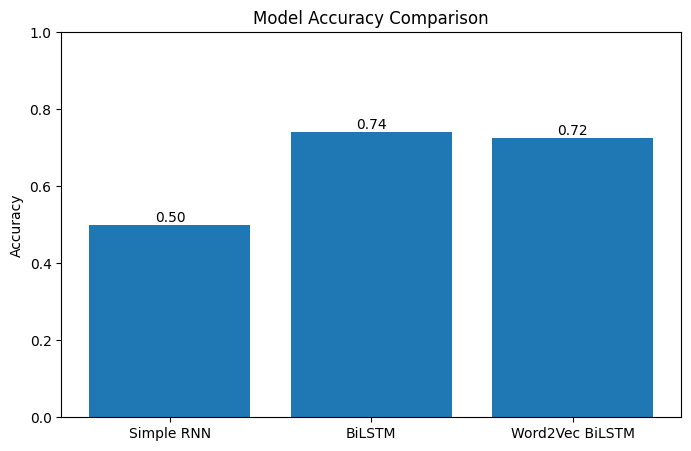

In [ ]:
# Compare All Models
model_names = [
    "Simple RNN",
    "BiLSTM",
    "Word2Vec BiLSTM"
]

accuracies = [
    accuracy,
    lstm_accuracy,
    w2v_accuracy
]

plt.figure(figsize=(8,5))

bars = plt.bar(model_names, accuracies)

plt.ylim(0,1)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

# Add values on top
for bar in bars:
    height = bar.get_height()
    
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.2f}',
        ha='center',
        va='bottom'
    )

plt.show()

In [ ]:
# Final Performance Table
comparison_df = pd.DataFrame({
    "Model": [
        "Simple RNN",
        "Bidirectional LSTM",
        "Word2Vec + BiLSTM"
    ],
    
    "Accuracy": [
        accuracy,
        lstm_accuracy,
        w2v_accuracy
    ]
})

comparison_df

,Model,Accuracy
0,Simple RNN,0.499167
1,Bidirectional LSTM,0.741250
2,Word2Vec + BiLSTM,0.725000


In [ ]:
# Sentiment Prediction Function
def predict_sentiment(review, model):
    
    # Clean review
    cleaned_review = clean_text(review)
    
    # Convert to sequence
    sequence = tokenizer.texts_to_sequences([cleaned_review])
    
    # Pad sequence
    padded_sequence = pad_sequences(
        sequence,
        maxlen=max_length,
        padding='post',
        truncating='post'
    )
    
    # Prediction
    prediction = model.predict(padded_sequence)
    
    # Get class index
    predicted_class = np.argmax(prediction)
    
    # Reverse label mapping
    reverse_mapping = {
        0: "Negative",
        1: "Neutral",
        2: "Positive"
    }
    
    sentiment = reverse_mapping[predicted_class]
    
    confidence = np.max(prediction) * 100
    
    return sentiment, confidence

In [ ]:
# Test Custom Reviews
sample_reviews = [
    "This book was absolutely amazing and inspiring.",
    
    "The story was average and sometimes boring.",
    
    "I hated this book. Waste of time."
]

for review in sample_reviews:
    
    sentiment, confidence = predict_sentiment(
        review,
        model_lstm
    )
    
    print(f"\nReview: {review}")
    print(f"Predicted Sentiment: {sentiment}")
    print(f"Confidence: {confidence:.2f}%")
    
    print("-"*60)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 805ms/step

Review: This book was absolutely amazing and inspiring.
Predicted Sentiment: Positive
Confidence: 63.34%
------------------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step

Review: The story was average and sometimes boring.
Predicted Sentiment: Negative
Confidence: 80.46%
------------------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step

Review: I hated this book. Waste of time.
Predicted Sentiment: Negative
Confidence: 92.04%
------------------------------------------------------------


In [84]:
!pip install gradio

In [89]:
def predict_with_all_models(review):
    
    # Clean text
    cleaned_review = clean_text(review)
    
    # Convert to sequence
    sequence = tokenizer.texts_to_sequences([cleaned_review])
    
    # Pad sequence
    padded_sequence = pad_sequences(
        sequence,
        maxlen=max_length,
        padding='post',
        truncating='post'
    )
    
    # Label mapping
    sentiment_mapping = {
        0: "Negative",
        1: "Neutral",
        2: "Positive"
    }
    
    # Function for prediction
    def get_prediction(model):
        
        prediction = model.predict(
            padded_sequence,
            verbose=0
        )
        
        predicted_class = np.argmax(prediction)
        
        sentiment = sentiment_mapping[predicted_class]
        
        confidence = float(np.max(prediction) * 100)
        
        return sentiment, confidence
    
    # Predictions from all models
    rnn_sentiment, rnn_conf = get_prediction(model_rnn)
    
    lstm_sentiment, lstm_conf = get_prediction(model_lstm)
    
    w2v_sentiment, w2v_conf = get_prediction(model_w2v)
    
    # Final formatted output
    result = f"""
================ SIMPLE RNN ================

Predicted Sentiment: {rnn_sentiment}

Confidence Score: {rnn_conf:.2f}%


================ BiLSTM ================

Predicted Sentiment: {lstm_sentiment}

Confidence Score: {lstm_conf:.2f}%


============= Word2Vec BiLSTM =============

Predicted Sentiment: {w2v_sentiment}

Confidence Score: {w2v_conf:.2f}%
"""
    
    return result

In [90]:
import gradio as gr

interface = gr.Interface(
    
    fn=predict_with_all_models,
    
    inputs=gr.Textbox(
        lines=10,
        placeholder="Enter a book review here..."
    ),
    
    outputs=gr.Textbox(
        lines=20,
        label="Sentiment Prediction Results"
    ),
    
    title="Book Review Sentiment Analysis System",
    
    description="""
Compare predictions from:
• Simple RNN
• Bidirectional LSTM
• Word2Vec + BiLSTM

Enter a book review to analyze sentiment.
""",
    
    theme="soft"
)

In [91]:
interface.launch()

* Running on local URL:  http://127.0.0.1:7861
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

* Running on public URL: https://a7d961d453ec84bf65.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
